# Treinamento do modelo de LSTM dos Top 100 Nasdaq

**Autores:**  
Bruno E A Hayek - RA: 10389776    
Xuan Zhu - RA: 10401714

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import torch
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

warnings.filterwarnings('ignore')
from src.stock_fetching import *
from src.nasdaq_forecast import *
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


file_pth = "datasets/nasdaq_dados.csv"


Dataset e símbolo da empresa selecionada

In [31]:
simbolo = 'NVDA' #Símbolo da empresa na NASDAQ

periodo =  '1y' #Período para pegar os dados da API

dias_previsao = 70

nasdaq_dados = carregar_dados(file_pth)

Informações do Dataset:
Shape: (271666, 13)
Colunas: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj_Close', 'Volume', 'Name', 'SMA_15', 'RSI', 'Retorno', 'Flutuacao_Diaria', 'Year']
Intervalo de datas: 2010-01-04 00:00:00 to 2021-09-10 00:00:00
Número de empresas: 102
Empresas: ['AAPL' 'ADBE' 'ADI' 'ADP' 'ADSK' 'AEP' 'ALGN' 'AMAT' 'AMD' 'AMGN']...
Valores nulos por coluna:
Date                0
Open                0
High                0
Low                 0
Close               0
Adj_Close           0
Volume              0
Name                0
SMA_15              0
RSI                 0
Retorno             0
Flutuacao_Diaria    0
Year                0
dtype: int64


Parâmetros para o modelo

In [32]:
test_ratio=0.2
epochs=50
batch_size=64
lr=1e-3
seq_len=60
target_col = 'Adj_Close'
feature_cols = ["Open", "High", "Low", "Close", "Adj_Close", "Volume", "SMA_15", "RSI", "Retorno", "Flutuacao_Diaria"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Criando a sequência dos dados

In [33]:
df_empresa = nasdaq_dados[nasdaq_dados['Name'] == simbolo].copy()

X, y = create_sequences(df_empresa,feature_cols,target_col,seq_len)

input_size = X.shape[2] 

Separando dados de treinamento

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_ratio, shuffle=False)
train_dataset = StockDataset(X_train, y_train)
test_dataset = StockDataset(X_test, y_test)

Criando dataloaders

In [35]:
train_loader = DataLoader(StockDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(StockDataset(X_test, y_test), batch_size=64)
print(f"Tamanho do dataloader de treinamento: {len(train_loader.dataset)}")
print(f"Tamanho do dataloader de teste: {len(test_loader.dataset)}")

Tamanho do dataloader de treinamento: 2306
Tamanho do dataloader de teste: 577


Instanciando o modelo e treinando

In [36]:
model = EnhancedLSTMModel(input_size=input_size, hidden_size=256, num_layers=3, dropout=0.3)

print(f"\nModelo inicializado no {DEVICE}")
print(f"Parâmetros do modelo: {sum(p.numel() for p in model.parameters()):,}")

history = enhanced_train(model, train_loader, test_loader, epochs, initial_lr=1e-3, patience=10, weight_decay=1e-5)



Modelo inicializado no cuda
Parâmetros do modelo: 1,368,321
Época   1 | Train Loss: 0.087422 | Val Loss: 1.532370 | LR: 1.00e-03
Época   2 | Train Loss: 0.014781 | Val Loss: 1.197785 | LR: 1.00e-03
Época   3 | Train Loss: 0.017191 | Val Loss: 1.341021 | LR: 1.00e-03
Época   4 | Train Loss: 0.010941 | Val Loss: 0.896455 | LR: 1.00e-03
Época   5 | Train Loss: 0.011905 | Val Loss: 1.125124 | LR: 1.00e-03
Época   6 | Train Loss: 0.009974 | Val Loss: 0.909992 | LR: 1.00e-03
Época   7 | Train Loss: 0.011913 | Val Loss: 0.845488 | LR: 1.00e-03
Época   8 | Train Loss: 0.009294 | Val Loss: 1.140457 | LR: 1.00e-03
Época   9 | Train Loss: 0.009169 | Val Loss: 0.942376 | LR: 1.00e-03
Época  10 | Train Loss: 0.008282 | Val Loss: 0.880275 | LR: 1.00e-03
Época  11 | Train Loss: 0.008044 | Val Loss: 0.854990 | LR: 1.00e-03
Época  12 | Train Loss: 0.007980 | Val Loss: 0.767667 | LR: 1.00e-03
Época  13 | Train Loss: 0.008078 | Val Loss: 0.953458 | LR: 1.00e-03
Época  14 | Train Loss: 0.007747 | Val Los

Avalição do modelo

In [37]:
predictions, actuals = evaluate_model(model, test_loader, scaler=None, return_predictions=False, device=DEVICE)

Test Metrics:
MSE: 0.4021
RMSE: 0.6341
MAE: 0.4053


Resultados

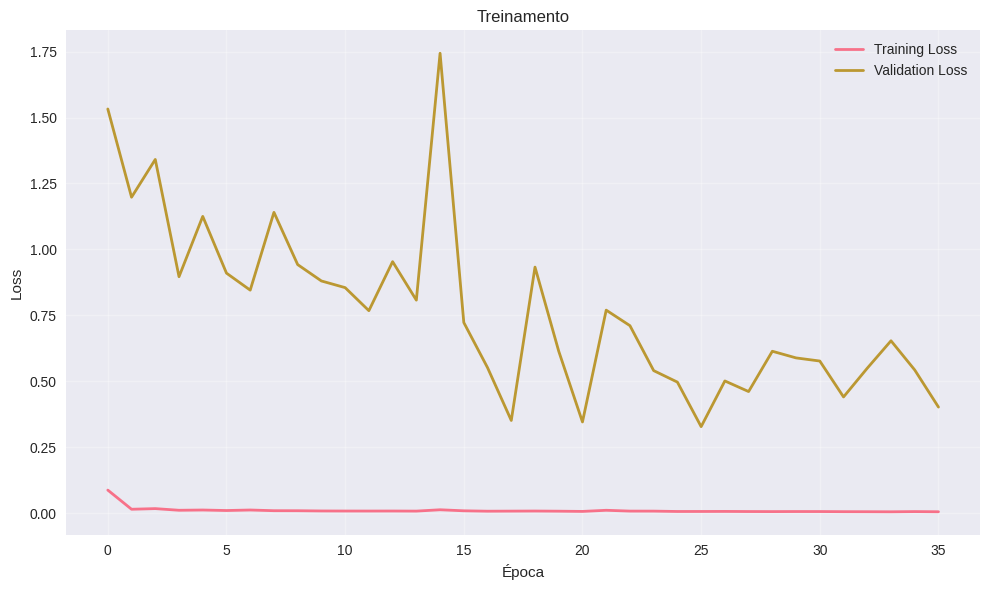

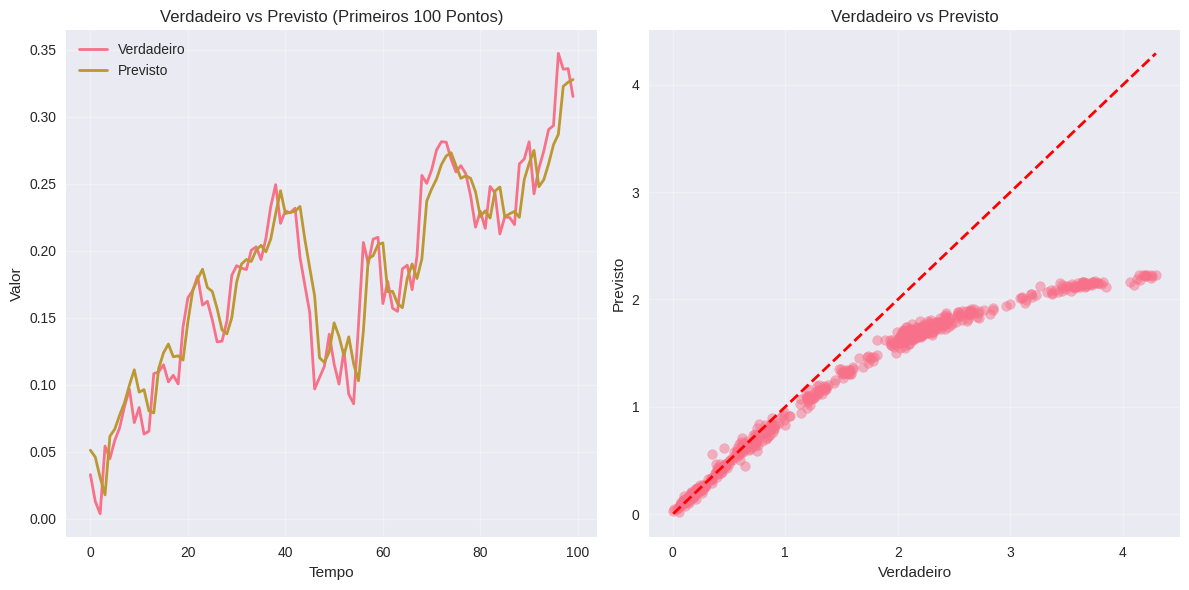

In [38]:
plot_history(history)
plot_predictions(actuals, predictions, title="Verdadeiro vs Previsto")

Salvando o modelo

In [39]:
torch.save(model.state_dict(), f"models/lstm_{simbolo}_model.pth")

# Predição de dados da API do Yahoo Finance

In [40]:
dados = fetch_stock_data(simbolo, period=periodo)

dados_normalizados = dados.copy()

dados_normalizados = normaliza_novo(dados_normalizados,simbolo)

X_input = sequencia_novo(dados_normalizados,target_col,feature_cols,seq_len)


In [41]:
model = EnhancedLSTMModel(input_size=input_size, hidden_size=256, num_layers=3, dropout=0.3)
model.load_state_dict(torch.load(f"models/lstm_{simbolo}_model.pth"))
model.to(DEVICE)
model.eval()

with torch.no_grad():
    next_value = model(X_input).item()

scaler = joblib.load(f"pkls/scaler_{simbolo}.pkl")

target_index = scaler.feature_names_in_.tolist().index(target_col)

mean = scaler.mean_[target_index]
scale = scaler.scale_[target_index]

real_next_value = next_value * scale + mean
print(f"Próximo preço de fechamento: {next_value:.2f}")


Próximo preço de fechamento: 0.77


In [42]:
previsoes = previsao_dias(dados_normalizados,simbolo,dias_previsao,model,X_input,target_col,feature_cols,seq_len)

Previsão para os próximos 70 dias (Adj_Close): [135.14588413 135.09815864 134.90084964 134.72382102 134.60269869
 134.52955264 134.48879261 134.46764619 134.45761132 134.45352963
 134.45243856 134.45271436 134.45351524 134.45442447 134.45526854
 134.45598986 134.45658313 134.45706427 134.45745524 134.45777347
 134.45803714 134.45825687 134.45844402 134.45860011 134.45873422
 134.45884787 134.45894637 134.45903123 134.45910246 134.45916307
 134.45921687 134.45926006 134.45929718 134.45933128 134.45935856
 134.45938356 134.4594025  134.45942145 134.45943357 134.45944721
 134.45945781 134.45946691 134.45947373 134.45948055 134.45948736
 134.45949115 134.45949721 134.45949949 134.45950328 134.45950479
 134.45950631 134.45950782 134.45950858 134.4595101  134.45951085
 134.45951161 134.45951313 134.45951085 134.45951085 134.4595101
 134.4595101  134.4595101  134.4595101  134.4595101  134.45950934
 134.45950858 134.45950858 134.45950934 134.4595101  134.45950934]


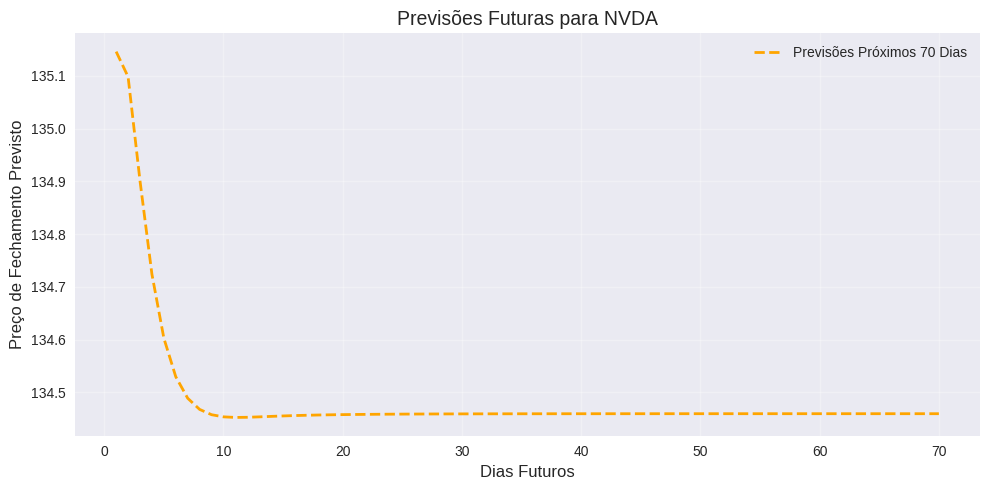

In [43]:
plot_previsao_apenas_previsoes(previsoes, dias_previsao, simbolo)

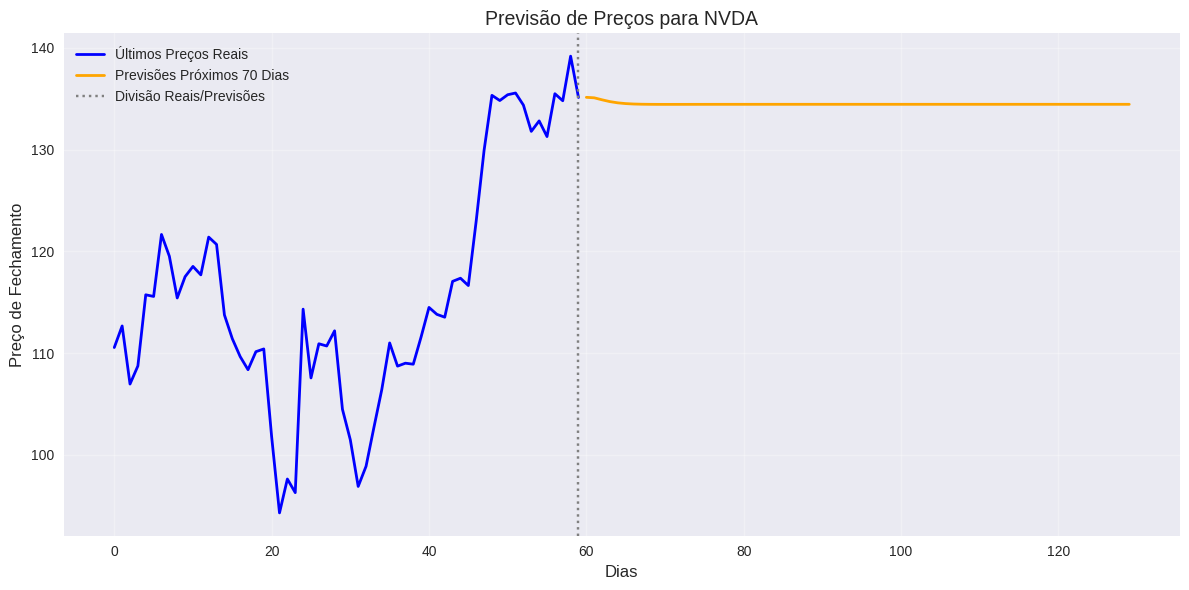

In [44]:
plot_previsao(dados,previsoes,target_col,dias_previsao,simbolo)